# CatalogIQ - Notebook 03: Finding similar products and spotting duplicates

**The business problem.** A shopper sees one product and wants "more like this". A seller wants to know whether
their photo is already listed. A catalog team wants to find the same product listed twice. All three need the
computer to judge *visual similarity* quickly across 42,000 products.

**How it works, in plain terms.** A pre-trained model called **CLIP** turns every photo (and every product
description) into a list of 512 numbers - a coordinate in a "meaning space" where similar things sit close
together. Searching then means "find the nearest coordinates". A **FAISS index** makes that nearest-neighbour
lookup fast.

**This notebook covers:** (1) how the embeddings were built, (2) exact vs approximate search speed,
(3) image search with examples and two failure cases, (4) text search, (5) "shop the look" outfit suggestions,
(6) duplicate detection tuned on 100 pairs labelled by hand, (7) a map of the whole catalog.

All logic lives in `src/catalogiq/search/`; the notebook calls it and draws charts.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from catalogiq.config import get_config, get_search_config, resolve_path
from catalogiq.search.duplicates import DuplicateFinder, duplicate_groups, load_phash
from catalogiq.search.embeddings import ClipEncoder, build_text, embed_catalog
from catalogiq.search.engine import SearchEngine
from catalogiq.search.labelcheck import compute_label_check, verified_mask
from catalogiq.search.looks import ShopTheLook
from catalogiq.search.viz import plot_pairs, plot_query_grid, tsne_coordinates
from catalogiq.vision.data import build_image_cache

cfg, scfg = get_config(), get_search_config()
FIG = resolve_path(cfg["paths"]["reports_figures"])
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
BLUE, ORANGE, GREY, GREEN = "#2f6fb0", "#e07b39", "#8a8f98", "#1b7f3b"

image_emb, text_emb, catalog = embed_catalog()          # cached: nothing is recomputed
images = np.asarray(build_image_cache()[0])
split = catalog["split"].to_numpy()
g_pos = np.where(np.isin(split, ["train", "val"]))[0]
test_pos = np.where(split == "test")[0]
gallery = SearchEngine(catalog.iloc[g_pos].reset_index(drop=True), image_emb[g_pos])
full = SearchEngine(catalog, image_emb, encoder=ClipEncoder())
def show_png(name, width=13):
    img = Image.open(FIG / name)
    plt.figure(figsize=(width, width * img.height / img.width)); plt.imshow(img); plt.axis("off"); plt.show()
print(f"{len(catalog):,} catalog photos | gallery (train+val) {len(g_pos):,} | test queries available {len(test_pos):,}")

2026-10-09 18:14:45,425 | INFO     | catalogiq.search.embeddings | loading cached CLIP embeddings from C:\CLAUDE PROJECTS\catalogiq\data\processed


42,257 catalog photos | gallery (train+val) 35,918 | test queries available 6,339


## 1. Embeddings: one coordinate per photo and per description

**What we did.** Every one of the 42,257 catalog photos, and a sentence built from each product's attributes
(for example *"a product photo of a black shirts for men, casual style, summer season"*), was turned into a
512-number vector with the OpenCLIP ViT-B/32 model (a 605 MB pre-trained file). The vectors were saved to disk so
nothing is ever recomputed.

**One practical detail.** The photos are tiny (about 60x80 pixels) with white backgrounds. CLIP's standard
preparation crops the picture to a square, which would cut off heads and shoes. We instead pad the photo with white
to a square first, then enlarge it. In Phase 2 we had used the standard crop for the zero-shot colour/type baseline;
re-running that check with padding (below) shows it made almost no difference.

In [2]:
sizes = {"image vectors": resolve_path(scfg["paths"]["image_emb"]), "text vectors": resolve_path(scfg["paths"]["text_emb"])}
print({k: f"{p.stat().st_size / 1e6:.1f} MB" for k, p in sizes.items()}, "| shape", image_emb.shape)
print("unique attribute sentences:", catalog["text"].nunique(), "(items with identical attributes share one sentence)")
print("vectors are unit length:", bool(np.allclose(np.linalg.norm(image_emb, axis=1), 1, atol=1e-4)))
for i in (0, 1, 2): print("  e.g.", catalog['text'][i])
pad = pd.read_csv(resolve_path("reports/clip_zero_shot_padded.csv"))
phase2 = pd.read_csv(resolve_path("reports/baselines.csv"))
phase2 = phase2[phase2["model"] == "zero-shot CLIP ViT-B/32"].set_index("target")
cmp = pad.set_index("target").join(phase2[["accuracy", "macro_f1"]], rsuffix="_phase2_crop")
cmp.round(3)

{'image vectors': '86.5 MB', 'text vectors': '86.5 MB'} | shape (42257, 512)
unique attribute sentences: 3091 (items with identical attributes share one sentence)
vectors are unit length: True
  e.g. a product photo of a blue shirts for men, casual style, fall season
  e.g. a product photo of a blue jeans for men, casual style, summer season
  e.g. a product photo of a grey watches for women, casual style, winter season


,accuracy,macro_f1,accuracy_phase2_crop,macro_f1_phase2_crop
target,,,,
articleType,0.681,0.689,0.688,0.683
baseColour,0.638,0.568,0.635,0.561
gender,0.846,0.533,0.858,0.570


**What we learned:** All 42,257 photos and their attribute sentences are now 512-number vectors, saved in two files of 86.5 MB each. Only 3,091 distinct sentences exist because products with the same attributes share one. Embedding the photos took roughly two hours of CPU at 5.7 to 7 photos per second (the laptop later ran faster: 60 ms for a single photo). Padding photos to a square instead of cropping made no consistent difference to the zero-shot results we reported in Phase 2: product type 0.681 accuracy vs 0.688, colour 0.638 vs 0.635, gender 0.846 vs 0.858 (macro-F1 0.689 vs 0.683, 0.568 vs 0.561 and 0.533 vs 0.570). The Phase 2 baseline therefore stands.

**Business takeaway:** Embedding is a one-time cost per product. After that, search works from saved numbers, and a newly uploaded photo only needs one extra 60 ms encoding step.

## 2. Exact vs approximate search: when does a marketplace need to switch?

Two ways to find the nearest neighbours: **exact** (compare the query with every product - always right, but the
time grows with the catalog) or **approximate** (HNSW builds a "road map" between products so a query only visits a
few hundred of them - far faster, with a small chance of missing a true neighbour). We measured both on the real
35,918-photo gallery, and on larger *synthetic* catalogs made by duplicating the real vectors with a little noise
(so the large-catalog numbers show speed trends, not real-world recall).

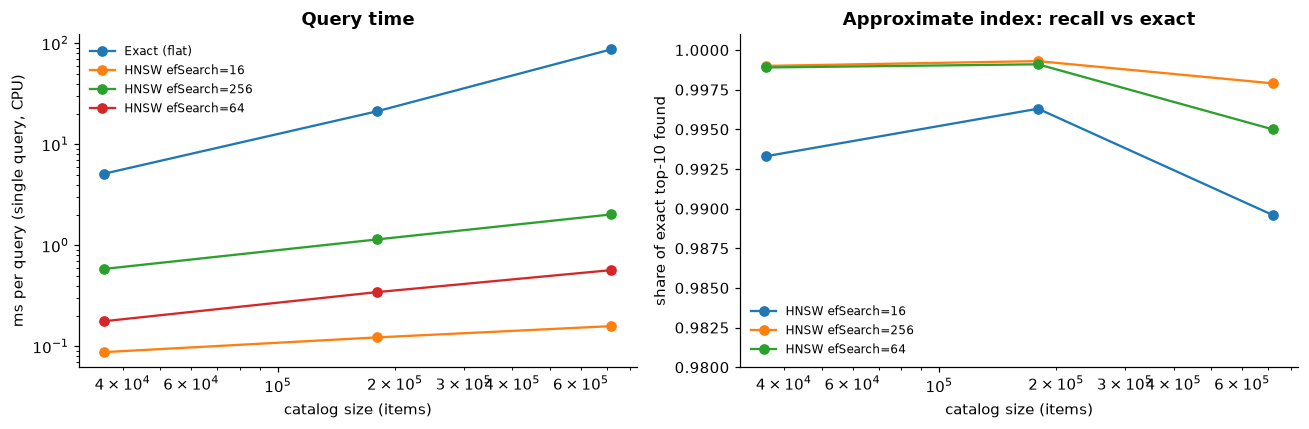

,catalog,index,build_s,single_ms_mean,single_ms_p95,batch_qps,recall@10_vs_flat,memory_mb
0,"35,918 items (real)",IndexFlatIP (exact),0.09,5.133,7.061,6502.8,1.0000,73.6
1,"35,918 items (real)","IndexHNSWFlat (M=32, efSearch=16)",2.72,0.088,0.118,64779.4,0.9933,NaN
2,"35,918 items (real)","IndexHNSWFlat (M=32, efSearch=64)",2.68,0.178,0.228,28287.4,0.9989,NaN
3,"35,918 items (real)","IndexHNSWFlat (M=32, efSearch=256)",3.01,0.586,0.774,9822.1,0.9990,NaN
4,"179,590 items (synthetic, real vectors + noise)",IndexFlatIP (exact),0.54,21.217,22.865,1232.5,1.0000,367.8
5,"179,590 items (synthetic, real vectors + noise)","IndexHNSWFlat (M=32, efSearch=16)",25.63,0.123,0.159,43319.7,0.9963,NaN
6,"179,590 items (synthetic, real vectors + noise)","IndexHNSWFlat (M=32, efSearch=64)",26.06,0.345,0.442,15264.0,0.9991,NaN
7,"179,590 items (synthetic, real vectors + noise)","IndexHNSWFlat (M=32, efSearch=256)",25.83,1.146,1.482,5809.0,0.9993,NaN
8,"718,360 items (synthetic, real vectors + noise)",IndexFlatIP (exact),2.57,87.221,91.944,308.6,1.0000,1471.2
9,"718,360 items (synthetic, real vectors + noise)","IndexHNSWFlat (M=32, efSearch=16)",179.82,0.159,0.211,26910.3,0.9896,NaN


In [3]:
ic = pd.read_csv(resolve_path("reports/index_comparison.csv"))
ic["items"] = ic["catalog"].str.extract(r"([\d,]+) items")[0].str.replace(",", "").astype(int)
ic["kind"] = np.where(ic["index"].str.startswith("IndexFlat"), "Exact (flat)", ic["index"].str.extract(r"(efSearch=\d+)")[0].radd("HNSW "))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for kind, d in ic.groupby("kind"):
    axes[0].plot(d["items"], d["single_ms_mean"], "o-", label=kind)
    if kind != "Exact (flat)": axes[1].plot(d["items"], d["recall@10_vs_flat"], "o-", label=kind)
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_xlabel("catalog size (items)"); axes[0].set_ylabel("ms per query (single query, CPU)")
axes[0].set_title("Query time"); axes[0].legend(frameon=False, fontsize=8)
axes[1].set_xscale("log"); axes[1].set_xlabel("catalog size (items)"); axes[1].set_ylabel("share of exact top-10 found"); axes[1].set_ylim(0.98, 1.001)
axes[1].set_title("Approximate index: recall vs exact"); axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "17_index_speed.png", bbox_inches="tight"); plt.show()
ic[["catalog", "index", "build_s", "single_ms_mean", "single_ms_p95", "batch_qps", "recall@10_vs_flat", "memory_mb"]]

**What we learned:** On the real 35,918-photo gallery an exact search takes 5.1 ms per query, while the approximate HNSW index takes 0.18 ms (efSearch 64) and still returns 99.9% of the exact top 10 (0.088 ms at 99.3% with efSearch 16, 0.59 ms at 99.9% with efSearch 256). HNSW costs a 2.7 second build instead of 0.09 seconds. On synthetic catalogs made by padding the real vectors with noise, exact search slows to 21 ms at 180k items and 87 ms at 718k, while HNSW stays at 0.35 ms and 0.57 ms with 99.5% to 99.9% recall (those recall figures are optimistic because the synthetic copies sit very close together).

**Business takeaway:** At our size (42k products) exact search is already instant (8 ms), perfectly accurate and lets filters work exactly, so keep it. A marketplace should switch to an approximate index when a query budget (say 50 ms) or traffic (thousands of searches a second) is threatened; on this CPU that point is around 400,000 products, by simple extrapolation of the timings above. The price is a longer build, extra memory (not measured here) and a small chance of missing a true neighbour.

## 3. Image search: examples

Each row is a query photo (blue frame) from the **test** set, followed by its five nearest products from the
**train + validation** gallery. Border colours show whether the result is the right kind of product:
**green** = same product type *and* same colour, **amber** = same type, different colour, **red** = different type.
Test photos are used as queries so that a product can never "find itself" or its own near-duplicate twin
(the Phase 1 split guarantees this).

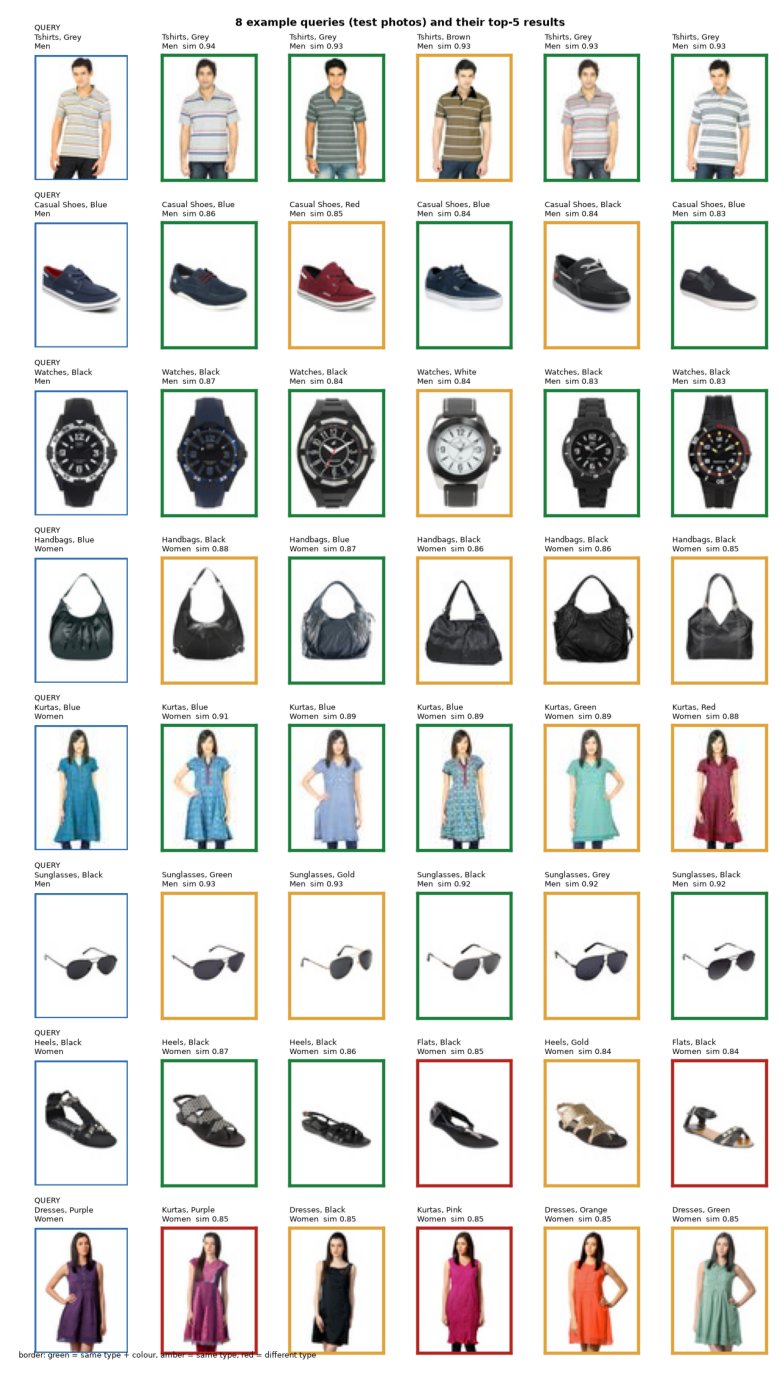

40 results (8 queries x top 5): {'same type + colour': 19, 'same type': 17, 'different type': 4}
right product type: 90% | right type AND colour: 48%


grade,different type,same type,same type + colour
query_type,,,
Casual Shoes,0,2,3
Dresses,2,3,0
Handbags,0,4,1
Heels,2,1,2
Kurtas,0,2,3
Sunglasses,0,3,2
Tshirts,0,1,4
Watches,0,1,4


In [4]:
show_png('13_search_examples.png', 9)
ex = pd.read_csv(resolve_path("reports/search_examples_results.csv"))
print("40 results (8 queries x top 5):", ex["grade"].value_counts().to_dict())
print(f"right product type: {(ex['grade'] != 'different type').mean():.0%} | right type AND colour: {(ex['grade'] == 'same type + colour').mean():.0%}")
ex.groupby("query_type")["grade"].value_counts().unstack(fill_value=0)

**What we learned:** Of the 40 results for the 8 example queries, 36 (90%) are the right kind of product and 19 (47.5%) also have the right colour; 17 are the right type in another colour and only 4 are a different type. Watches and T-shirts do best (4 of 5 results match type and colour); colour is the weak spot for dresses (none of 5 match, two results are kurtas) and handbags (1 of 5, because a dark blue bag retrieves black bags). The four wrong-type results come from two queries: heels returned two flat sandals, and a dress returned two kurtas. These are the same boundary classes the Phase 2 classifier finds hard.

**Business takeaway:** For a shopper clicking 'more like this', results are almost always the right product type, and showing other colours of the same item is usually a feature, not a bug. The grid also shows the limit of purely visual search: it cannot know that a shopper wants the same colour, which is why the filters below matter.

### Two failure cases, explained

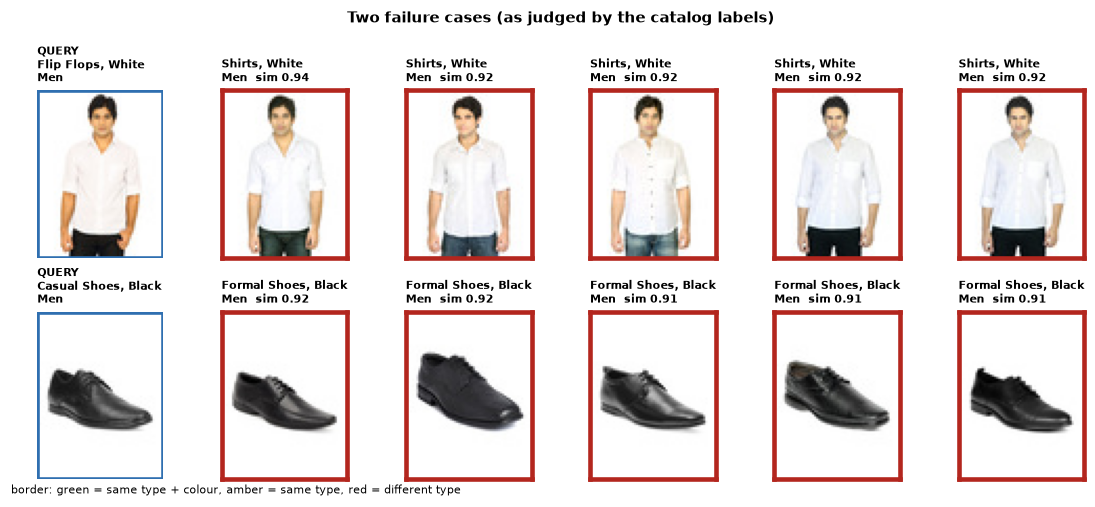

In [5]:
fail_ids = [10804, 57496]
pos = {int(i): p for p, i in enumerate(catalog["id"])}
triples = []
for i in fail_ids:
    p = pos[i]; res = gallery.search_vector(image_emb[p], k=5)
    triples.append((catalog.iloc[p], images[p], res))
plot_query_grid(images, catalog, triples, None, "Two failure cases (as judged by the catalog labels)"); plt.show()

**What we learned:** These two 'failures' are mostly catalog problems, not search problems. **Left:** the query is catalogued as 'Flip Flops, White', but the photo is a man in a white shirt; the search correctly returns white shirts, so the search is right and the label is wrong. This is the same kind of label error found in Phase 2 (about 10% of the product-type mistakes we reviewed). **Right:** a black lace-up shoe is catalogued as 'Casual Shoes', but every result is a 'Formal Shoes' item; visually these are the same kind of shoe, and the casual-vs-formal line is exactly the boundary that confused the Phase 2 classifier. A genuine visual weakness is the sandal family: thong sandals labelled Flip Flops, Flats and Heels look alike (see the failure candidates in `reports/figures/14_search_failures.png`).

**Business takeaway:** Visual search is a free quality check on the catalog: when a photo's nearest neighbours all carry a different label, either the label is wrong or the taxonomy is blurry. Our evaluation counts these as misses, so the scores below understate how useful the results look to a shopper.

### Filters: narrowing results by attribute

no filter          -> {'Men': 5} {'Black': 2, 'Grey': 2, 'Brown': 1}
only Women         -> {'Women': 5} {'Black': 5}
only Red or Pink   -> {'Men': 5} {'Red': 5}


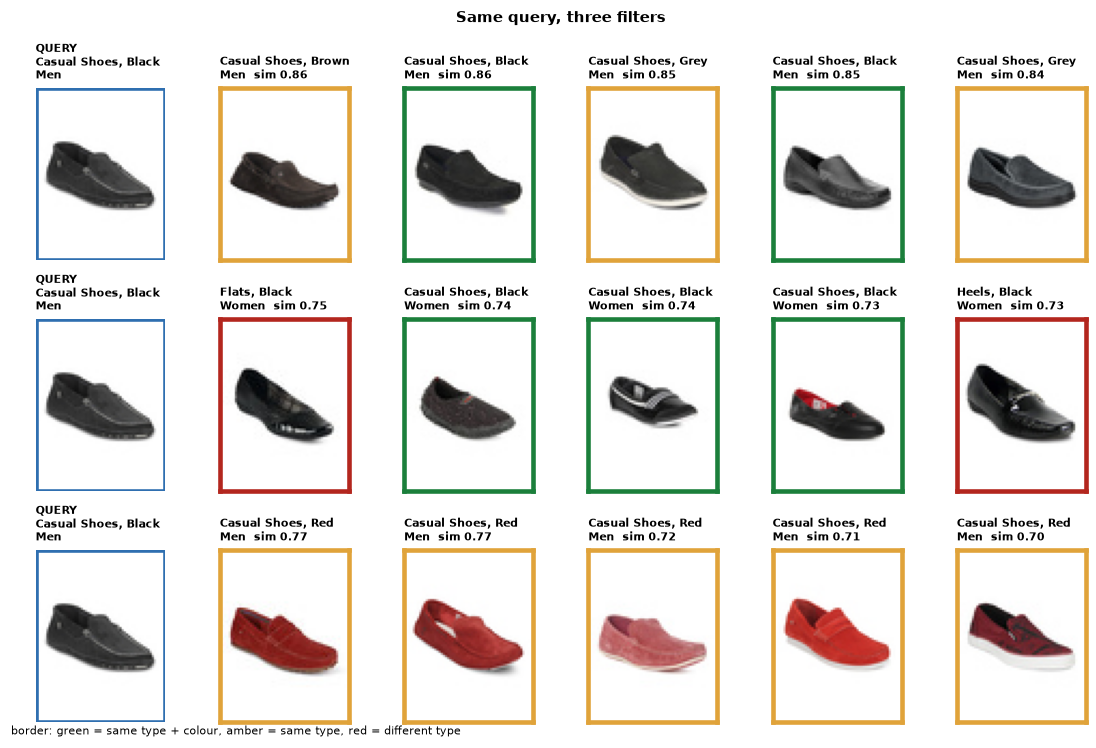

In [6]:
q = pos[int(catalog.loc[(catalog["articleType"] == "Casual Shoes") & (catalog["split"] == "test")].iloc[2]["id"])]
rows = []
for label, flt in [("no filter", None), ("only Women", {"gender": "Women"}), ("only Red or Pink", {"baseColour": ["Red", "Pink"]})]:
    res = gallery.search_vector(image_emb[q], k=5, filters=flt)
    rows.append((catalog.iloc[q], images[q], res)); print(f"{label:18s} -> {res['gender'].value_counts().to_dict()} {res['baseColour'].value_counts().to_dict()}")
plot_query_grid(images, catalog, rows, None, "Same query, three filters"); plt.show()

### How good is it? Measured on 1,995 test queries

**Relevant** means *the same product type and the same colour* as the query. **Recall@k** = share of queries that
have at least one relevant product in the top k. **mAP@10** is a stricter score that also rewards putting
relevant products *early*. The comparison rows show what happens if we search with our own Phase 2 classifier's
internal features instead of CLIP. *Fairness note:* that classifier was trained on exactly these type and colour
labels, so it is a "supervised" competitor, whereas CLIP was never trained on our data.

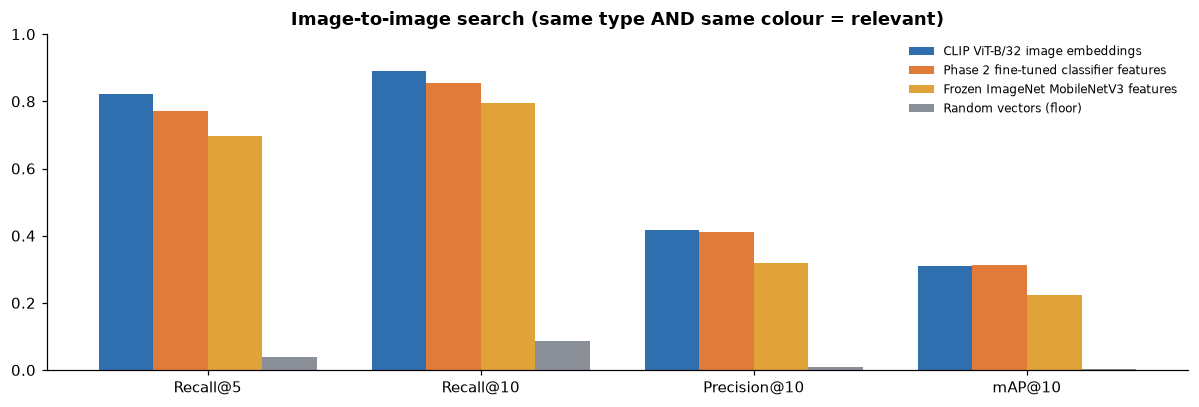

,representation,queries,queries_without_relevant,recall@5,recall@10,precision@10,mAP@10,precision@10_articleType_only
0,CLIP ViT-B/32 image embeddings,1995,5,0.8231,0.8897,0.4182,0.3092,0.8726
1,Phase 2 fine-tuned classifier features,1995,5,0.7724,0.8536,0.4118,0.3118,0.8012
2,Frozen ImageNet MobileNetV3 features,1995,5,0.6982,0.7960,0.3192,0.2225,0.7409
3,Random vectors (floor),1995,5,0.0401,0.0877,0.0099,0.0025,0.0554


In [7]:
sm = pd.read_csv(resolve_path("reports/search_metrics.csv"))
fig, ax = plt.subplots(figsize=(11, 3.8))
cols = ["recall@5", "recall@10", "precision@10", "mAP@10"]
w = 0.2
for i, (_, r) in enumerate(sm.iterrows()):
    ax.bar(np.arange(len(cols)) + (i - 1.5) * w, [r[c] for c in cols], w, label=r["representation"],
           color=[BLUE, ORANGE, "#e0a33a", GREY][i])
ax.set_xticks(range(len(cols))); ax.set_xticklabels(["Recall@5", "Recall@10", "Precision@10", "mAP@10"])
ax.set_ylim(0, 1); ax.legend(frameon=False, fontsize=8); ax.set_title("Image-to-image search (same type AND same colour = relevant)")
plt.tight_layout(); plt.savefig(FIG / "18_search_metrics.png", bbox_inches="tight"); plt.show()
sm

**What we learned:** Using zero-shot CLIP (never trained on our data), the right type and colour is among the top 5 results for 82.3% of 1,995 test queries and among the top 10 for 89.0%; on average 4.2 of 10 results match both type and colour, and 8.7 of 10 match the type alone (mAP@10 0.309). The Phase 2 classifier's internal features, which were trained on exactly these type and colour labels, reach lower recall (77.2% and 85.4%) but a similar mAP (0.312), and clearly lower type-only precision (0.801 vs 0.873). Frozen ImageNet features are worse again (79.6% at 10, mAP 0.223), and random vectors give 8.8%. Caveat: colour labels are noisy (44% of look-alike photo groups disagreed on colour in Phase 1), so 'same type and colour' is a hard yardstick.

**Business takeaway:** A general-purpose model beats our own trained one at finding similar products, with no training at all, and it is the better foundation for visual search. The classifier is better kept for filling in attributes. A sensible product combines them: CLIP to retrieve, attribute filters to narrow.

## 4. Text search

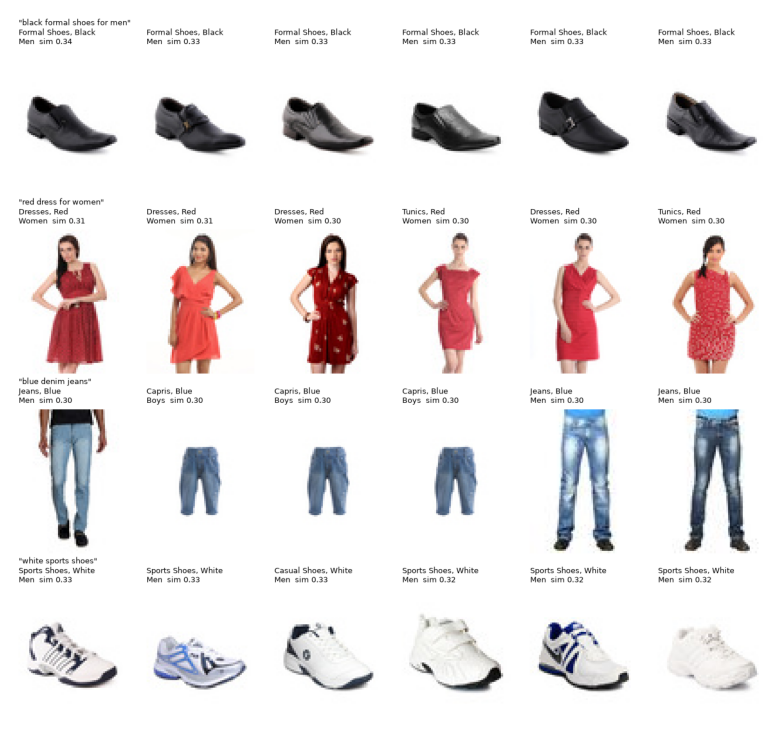

In [8]:
show_png('15_text_search.png', 9)

In [9]:
tm = pd.read_csv(resolve_path("reports/text_search_metrics.csv"))
tq = pd.read_csv(resolve_path("reports/text_queries_used.csv"))
print("300 attribute-combination queries, e.g.:", tq["query"].head(5).tolist())
tm

300 attribute-combination queries, e.g.: ['blue ties for men', 'brown sandals for unisex', 'black skirts for women', 'blue clutches for women', 'grey night suits for men']


,method,queries,recall@10,precision@10,mAP@10
0,CLIP text -> image embeddings,300,0.8867,0.4513,0.3718
1,Random gallery items (floor),300,0.0167,0.0017,0.0003
2,CLIP text -> attribute-sentence embeddings (re...,300,0.9400,0.8433,0.9027


**What we learned:** Typing a description finds the right products: on 300 attribute-style queries (such as 'blue ties for men' or 'black skirts for women') at least one correct product is in the top 10 for 88.7% of queries (random guessing: 1.7%), and 4.5 of the top 10 on average match colour, type and gender (mAP@10 0.372). The example grid shows 'black formal shoes for men' returning six black formal shoes and 'red dress for women' returning red dresses and tunics; 'blue denim jeans' returned jeans plus boys' denim capris, a reasonable reading of the words. For reference, matching the text against the products' attribute sentences (not images) reaches 0.94 recall and 0.90 mAP, which is the ceiling of what the descriptions themselves can express. Some test queries were unnatural combinations such as 'brown sandals for unisex'.

**Business takeaway:** Search by words works without any extra training, including for products with weak or missing titles, since the match is made on the picture. It is a cheap upgrade for a marketplace search box.

## 5. Shop the look

Given one item, suggest **complementary** products from *other* categories (a shirt -> trousers, shoes, a watch, a
bag). This uses plain, explainable rules on top of the embeddings, not another trained model:

* **Hard rules:** the item must come from a complementary category; gender must be compatible (same or unisex);
  the two article types must share a **style family** (casual, formal, sporty, ethnic or party - so formal trousers
  never get sports shoes); and the catalog label must be **confirmed by our Phase 2 classifier**, so mislabelled
  photos never appear in a look.
* **Score (0-1):** 30% style-family pairing, 30% colour compatibility (neutrals go with everything, plus a curated
  list of pleasing pairs), 15% same usage, 10% same season, 15% visual style similarity from CLIP.

Every suggestion lists its reasons. Full rule table: `docs/search_design.md`.

catalog items whose label the classifier confirms: 84.1% (35,558 of 42,257)
lowest-confidence disagreements by article type (items the look rules will skip):
articleType
Tunics     0.07
Flats      0.19
Kurtis     0.24
Jackets    0.52
Skirts     0.54
Capris     0.54


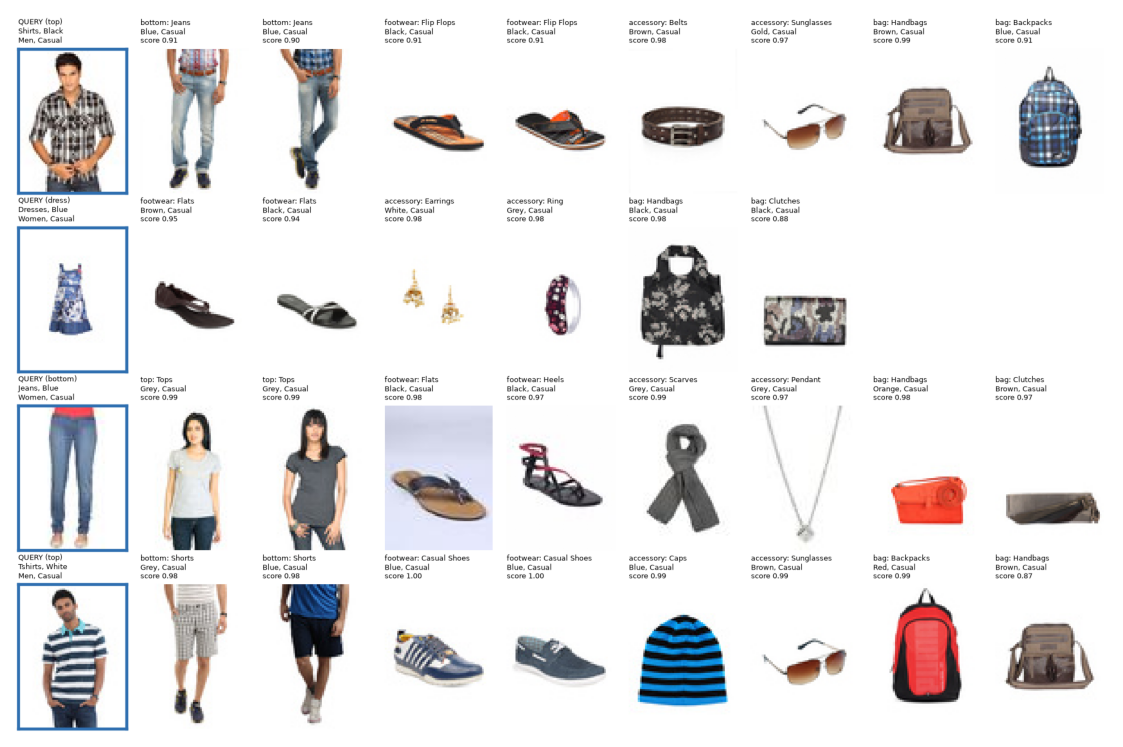

,role,articleType,baseColour,score,reasons
0,bottom,Jeans,Blue,0.906829,both casual style; same usage (Casual); same s...
1,footwear,Flip Flops,Black,0.909651,both casual style; same usage (Casual); same s...
2,accessory,Belts,Brown,0.979454,both casual/formal style; same usage (Casual);...
3,bag,Handbags,Brown,0.985775,both casual/formal style; same usage (Casual);...


In [10]:
check = compute_label_check()
verified = verified_mask(catalog, check, scfg["shop_the_look"]["verify_min_confidence"])
print(f"catalog items whose label the classifier confirms: {verified.mean():.1%} ({int(verified.sum()):,} of {len(verified):,})")
print("lowest-confidence disagreements by article type (items the look rules will skip):")
print(catalog.assign(ok=verified).groupby("articleType")["ok"].mean().sort_values().head(6).round(2).to_string())
show_png('16_shop_the_look.png', 13)
stl = ShopTheLook(full, verified=verified)
sample_id = int(catalog[(catalog["articleType"] == "Shirts") & (catalog["gender"] == "Men") & (catalog["split"] == "test")]["id"].iloc[3])
look = stl.recommend(sample_id, per_category=1)
look.items[["role", "articleType", "baseColour", "score", "reasons"]]

**What we learned:** The rules produce coherent outfits: a black casual shirt gets blue jeans, flip-flops, a brown belt, sunglasses and a handbag or backpack; a dress gets flats, earrings, a ring and a clutch; a white T-shirt gets shorts, casual shoes, a cap and a backpack. Every recommendation lists why it was chosen. My first version, which relied mostly on visual similarity, produced poor looks (flip-flops with a shirt, a scarf and a cap by default) and exposed mislabelled photos, so I added the style-family rule and a gate that only allows items whose label the Phase 2 classifier confirms (35,558 of 42,257 items, 84.1%). The gate has a side effect: the classes the classifier is weakest on are mostly filtered out (only 7% of Tunics, 19% of Flats and 24% of Kurtis are confirmed), so looks rarely feature them. Limits: there is no ground truth for outfit quality, I judged only four examples by eye, the pairing table and weights are hand-written and untuned, and the 'style fit' is relative (the best-looking item among the sensible candidates always scores near 1).

**Business takeaway:** A transparent rule set is enough to give believable 'complete the outfit' suggestions today, and each suggestion can be explained to a shopper or a merchandiser. Whether it increases sales is unproven and would need an A/B test.

## 6. Duplicate detection

**Goal:** flag two listings that are the *same product* so a marketplace can merge or remove the copy.
A pair is flagged when (a) the CLIP similarity is above a threshold **and** (b) a classic *perceptual hash* (a 64-bit
fingerprint of the picture) agrees within a few bits. CLIP finds the same product even when the photo was re-shot or
re-cropped; the hash vetoes look-alike but different products.

**How the threshold was chosen:** we sampled **100 candidate pairs** across four similarity bands, you labelled each
one by eye (*duplicate* / *not a duplicate* / *unsure*), and we picked the **lowest threshold whose precision is at
least 95%** (a wrong "duplicate" can hide a legitimate listing, so we protect precision first). Because the sample
over-represents high-similarity pairs, each pair is weighted by how many real candidate pairs it stands for.

labels file: reports/duplicate_labels_ai_provisional.csv <- AI-provisional labels unless this says duplicate_labels.csv
labels: {'pairs_total': 100, 'duplicate': 38, 'not_duplicate': 58, 'unsure': 4, 'blank': 0}
labelled duplicates per similarity band:
label         duplicate  not duplicate
bin                                   
[0.8, 0.9)            0             25
[0.9, 0.95)           4             19
[0.95, 0.98)          9             14
[0.98, 1.0)          25              0
UNWEIGHTED on the 96 labelled pairs at 0.975: flagged 27, of which duplicates 27; duplicates missed 11 of 38
{'recommended_threshold': 0.975, 'recommended_precision': 1.0, 'recommended_recall': 0.2192, 'f1_optimal_threshold': 0.935, 'f1_optimal_precision': 0.5796, 'f1_optimal_recall': 0.4187, 'rule': 'lowest threshold with weighted precision >= 0.95 (similarity + pHash <= 8)'}


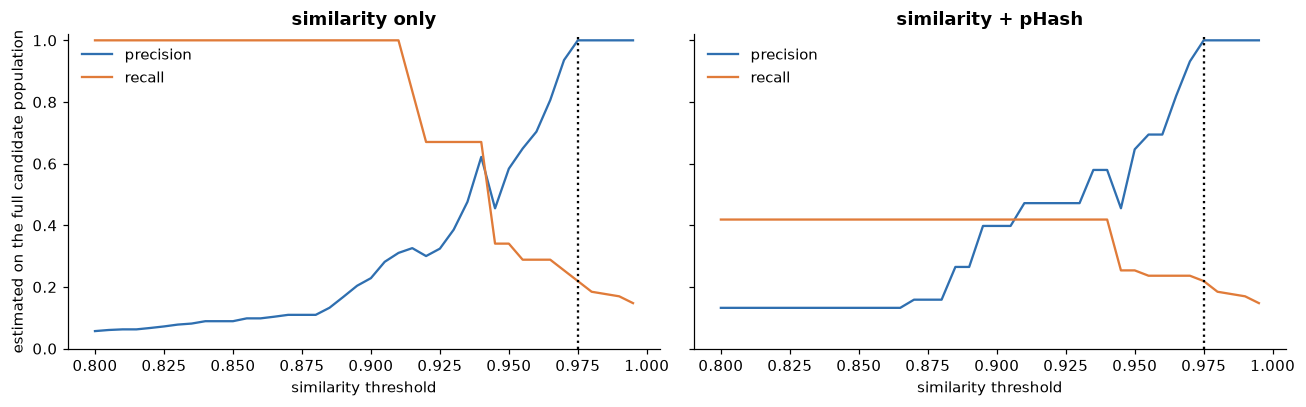

pHash alone:
 pHash max distance  precision  recall
                  0     0.9162  0.1896
                  2     0.7595  0.2192
                  4     0.3255  0.4014
                  8     0.1323  0.4187
                 12     0.0699  0.4707
                 16     0.0856  0.8351


In [11]:
stats = json.loads(resolve_path("reports/duplicate_label_stats.json").read_text())
res = json.loads(resolve_path("reports/duplicate_threshold.json").read_text())
ev = pd.read_csv(resolve_path("reports/duplicate_threshold_eval.csv"))
print("labels file:", stats.get("labels_file"), "<- AI-provisional labels unless this says duplicate_labels.csv")
print("labels:", {k: v for k, v in stats.items() if k != "labels_file"})
lp = pd.read_csv(resolve_path(scfg["duplicates"]["pairs_csv"])).drop(columns=["label"]).merge(
    pd.read_csv(resolve_path(stats["labels_file"]), dtype={"label": str})[["pair_id", "label"]], on="pair_id")
lp = lp[lp["label"].isin(["0", "1"])].assign(label=lambda d: d["label"].astype(int))
print("labelled duplicates per similarity band:"); print(pd.crosstab(lp["bin"], lp["label"].map({0: "not duplicate", 1: "duplicate"})).to_string())
thr_ = res["recommended_threshold"]
flag = (lp["similarity"] >= thr_) & (lp["phash_distance"] <= res["phash_max_distance"])
print(f"UNWEIGHTED on the 96 labelled pairs at {thr_}: flagged {int(flag.sum())}, of which duplicates {int(lp.loc[flag, 'label'].sum())}; duplicates missed {int(lp.loc[~flag, 'label'].sum())} of {int(lp['label'].sum())}")
print({k: res[k] for k in ["recommended_threshold", "recommended_precision", "recommended_recall", "f1_optimal_threshold", "f1_optimal_precision", "f1_optimal_recall", "rule"]})
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, method in zip(axes, ["similarity only", "similarity + pHash"]):
    d = ev[ev["method"] == method]
    ax.plot(d["threshold"], d["precision"], "-", color=BLUE, label="precision"); ax.plot(d["threshold"], d["recall"], "-", color=ORANGE, label="recall")
    ax.axvline(res["recommended_threshold"], ls=":", color="k"); ax.set_title(method); ax.set_xlabel("similarity threshold"); ax.legend(frameon=False)
axes[0].set_ylabel("estimated on the full candidate population"); axes[0].set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(FIG / "19_duplicate_threshold.png", bbox_inches="tight"); plt.show()
print("pHash alone:"); print(pd.DataFrame(res["pHash_only"]).to_string(index=False))

**Important: the labels used here are provisional.** You offered to label the 100 pairs; at your request I labelled them myself (blind to the similarity scores), so these numbers carry one AI reviewer's judgement, not yours. They are saved as `reports/duplicate_labels_ai_provisional.csv` and can be replaced by running `scripts/tune_duplicates.py` on your own labels.

**What we learned:** Of the 96 pairs with a decision (4 were unsure), 38 are duplicates. The similarity bands behave very differently: the top band (0.98 and above) is 25 of 25 duplicates, 0.95 to 0.98 is 9 of 23, 0.90 to 0.95 is 4 of 23, and 0.80 to 0.90 is 0 of 25. Following the rule of the lowest threshold with at least 95% precision gives **0.975**: all 27 sample pairs flagged at that level are duplicates (so precision is about 100%, and by a standard small-sample bound at least about 89%). It finds 27 of the 38 duplicates in the sample (71%), but weighted to the whole candidate population the estimated recall is only 22%, because the few duplicates in the 0.90 to 0.95 band (4 labelled pairs) each stand for about 1,500 real pairs, which makes recall below 0.95 very uncertain. Comparing methods: at 0.975 the perceptual hash adds nothing (similarity alone is already precise there), and the hash by itself is a poor detector (distance 0: 92% precision but 19% recall; distance 16: 84% recall but 9% precision). The best-F1 setting (0.935) trades precision down to 58%.

**Business takeaway:** Use a high-precision rule for automatic suggestions (0.975 and above) and treat the 0.95 to 0.98 band, where about 40% of sampled pairs (9 of 23) are real duplicates, as a human review queue. Do not lower the threshold to chase recall without a review step: below 0.95, 44 of the 48 sampled pairs are different products, often colour variants of the same style, which a marketplace should keep.

### What the detector finds in the whole catalog

2026-10-09 18:15:23,747 | INFO     | catalogiq.search.duplicates | 184458 candidate pairs with similarity >= 0.75


threshold 0.975: 1,833 duplicate pairs, 2,143 products involved in 875 groups (largest group 26)
pairs by item split pairing: col_0  test  train  val
row_0                  
test    205     62   15
train    73   1109   76
val       9     58  226


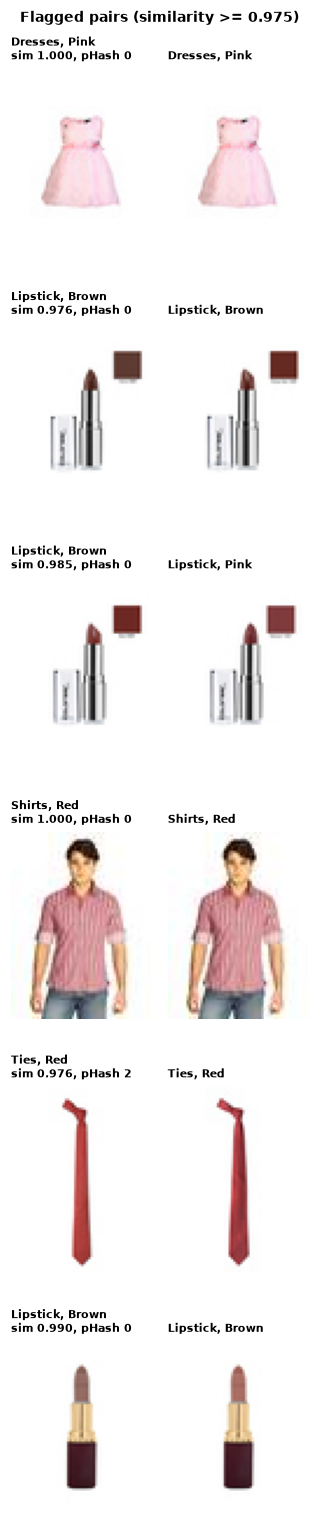

2,169 pairs just below the threshold (within 0.03) that the hash would still accept - examples:


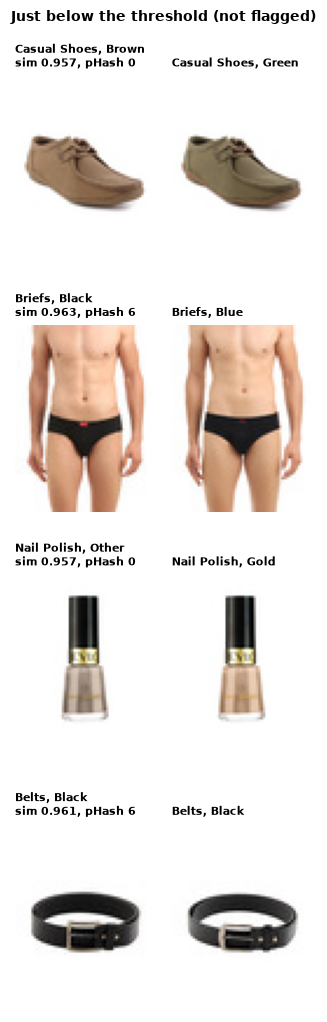

In [12]:
phash = load_phash(catalog["id"])
finder = DuplicateFinder(catalog, image_emb, phash)
thr = res["recommended_threshold"]
dups = finder.find_duplicates(thr)
groups = duplicate_groups(dups)
sizes = pd.Series(groups).value_counts()
print(f"threshold {thr:.3f}: {len(dups):,} duplicate pairs, {len(groups):,} products involved in {len(sizes):,} groups (largest group {sizes.max()})")
print("pairs by item split pairing:", pd.crosstab(catalog.set_index('id').loc[dups['id_a'], 'split'].to_numpy(), catalog.set_index('id').loc[dups['id_b'], 'split'].to_numpy()).to_string())
plot_pairs(images, catalog, dups.sample(min(6, len(dups)), random_state=1), n=6, path="reports/figures/21_flagged_pairs.png", title=f"Flagged pairs (similarity >= {thr:.3f})"); plt.show()
near = finder.candidate_pairs()
near = near[(near["similarity"] < thr) & (near["similarity"] >= thr - 0.03) & (near["phash_distance"] <= scfg["duplicates"]["phash_max_distance"])]
print(f"{len(near):,} pairs just below the threshold (within 0.03) that the hash would still accept - examples:")
plot_pairs(images, catalog, near.sample(min(4, len(near)), random_state=1), n=4, path="reports/figures/22_near_threshold_pairs.png", title="Just below the threshold (not flagged)"); plt.show()

**What we learned:** At threshold 0.975 (with the hash agreeing within 8 bits) the detector flags 1,833 duplicate pairs, linking 2,143 products (5.1% of the catalog) in 875 groups, the largest with 26 listings. The flagged examples are true copies (the same dress, shirt, tie and lipstick). One weakness is visible: two flagged lipstick pairs differ only in the colour swatch, i.e. shade variants of one product that a person would not treat as duplicates, because CLIP cannot see such small colour differences. The pairs just below the threshold are mostly colourways (brown vs green shoes, black vs blue briefs, different nail-polish shades), so leaving them unflagged is right.

**Business takeaway:** About 1 listing in 20 sits in a duplicate group, which is real clutter in search results. For cosmetics, where shades are sold as separate products, a colour check on the shade should be added before auto-merging.

### A by-product: did duplicates leak between our train and test sets?

In Phase 1 we kept near-identical photos in the same split (by perceptual hash). The CLIP detector also finds
*re-shot* copies the hash missed. How many test photos have a twin in the training or validation data, and does
that inflate our earlier results?

In [13]:
sp = catalog.set_index("id")["split"]
d2 = dups.assign(sa=sp.loc[dups["id_a"]].to_numpy(), sb=sp.loc[dups["id_b"]].to_numpy())
cross = d2[d2["sa"] != d2["sb"]]
test_ids = set(cross.loc[cross["sa"] == "test", "id_a"]) | set(cross.loc[cross["sb"] == "test", "id_b"])
n_test = int((catalog["split"] == "test").sum())
print(f"duplicate pairs spanning two splits: {len(cross)} of {len(d2)} ({len(cross) / len(d2):.0%})")
print(f"test photos with a duplicate in train/val: {len(test_ids)} of {n_test:,} ({len(test_ids) / n_test:.1%})")

# Phase 2 product-type accuracy with and without those photos
probs = np.load(resolve_path("data/interim/test_probs_full.npz"))["articleType"]
classes = json.loads((resolve_path(get_config()["paths"]["models"]) / "attribute_classifier" / "labels.json").read_text())["articleType"]
test = catalog[catalog["split"] == "test"].reset_index(drop=True)
hit = np.array(classes)[probs.argmax(1)] == test["articleType"].to_numpy()
has_twin = test["id"].isin(test_ids).to_numpy()
print(f"Phase 2 articleType accuracy: all {hit.mean():.3f} | with twin {hit[has_twin].mean():.3f} (n={has_twin.sum()}) | without twin {hit[~has_twin].mean():.3f} (n={(~has_twin).sum()})")

# Search metrics with and without queries that have a twin in the gallery
from catalogiq.search.metrics import average_precision_at_k, count_relevant, precision_at_k, recall_at_k, relevance_matrix
rng = np.random.default_rng(42)
q = np.sort(rng.choice(test_pos, 2000, replace=False)); qa = catalog.iloc[q].reset_index(drop=True)
keys = ["articleType", "baseColour"]; gal = gallery.catalog
ranked = gallery.search_matrix(image_emb[q], 10); n_rel = count_relevant(qa, gal, keys); okq = n_rel > 0
rel = relevance_matrix(qa, gal, ranked, keys); tw = qa["id"].isin(test_ids).to_numpy()
rows = []
for name, m in [("all queries", okq), ("queries with a twin in the gallery", okq & tw), ("queries without a twin", okq & ~tw)]:
    rows.append({"queries": name, "n": int(m.sum()), "recall@5": round(recall_at_k(rel[m], 5), 3), "recall@10": round(recall_at_k(rel[m], 10), 3), "mAP@10": round(average_precision_at_k(rel[m], n_rel[m], 10), 3)})
pd.DataFrame(rows)

duplicate pairs spanning two splits: 293 of 1833 (16%)
test photos with a duplicate in train/val: 71 of 6,339 (1.1%)
Phase 2 articleType accuracy: all 0.857 | with twin 0.986 (n=71) | without twin 0.855 (n=6268)


,queries,n,recall@5,recall@10,mAP@10
0,all queries,1995,0.823,0.890,0.309
1,queries with a twin in the gallery,21,0.857,0.905,0.345
2,queries without a twin,1974,0.823,0.890,0.309


**What we learned:** 293 of the 1,833 duplicate pairs (16%) link photos in different splits, because the Phase 1 grouping only caught identical hashes, not re-shot copies. Only 71 of the 6,339 test photos (1.1%) have such a twin in the training or validation data. The Phase 2 classifier gets those 71 right 98.6% of the time versus 85.5% for the others, but because there are so few, removing them changes the overall product-type accuracy only from 85.7% to 85.5%. For search, the 21 of 1,995 queries with a twin in the gallery score slightly higher (Recall@10 0.905 vs 0.890) and the overall figures are unchanged at this precision.

**Business takeaway:** The earlier results hold up: leakage exists but is too small to change any conclusion. For future retraining, the split rule should group by the CLIP duplicate detector as well as the hash.

## 7. A map of the whole catalog

To see the structure CLIP has learned, we squash the 512 numbers of 6,000 randomly chosen products into 2D with
**t-SNE** (a technique that keeps neighbours close; distances *between* far-apart clusters are not meaningful).

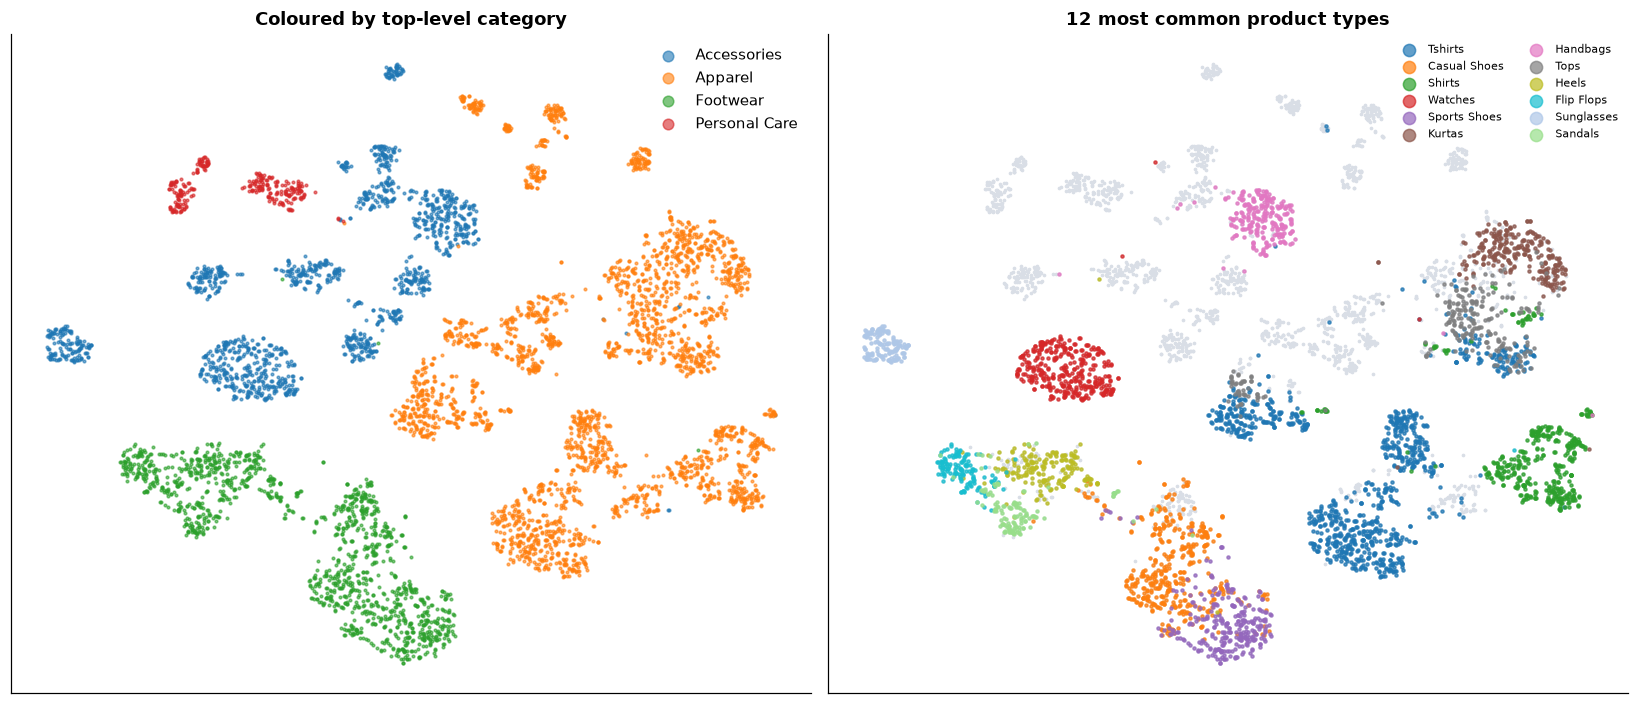

In [14]:
pos_sub, xy = tsne_coordinates(image_emb, n=6000, seed=42, cache="data/interim/tsne_clip_6000.npz")
sub = catalog.iloc[pos_sub].reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for cat, d in sub.groupby("masterCategory"):
    axes[0].scatter(xy[d.index, 0], xy[d.index, 1], s=3, alpha=0.6, label=cat)
axes[0].legend(markerscale=4, frameon=False); axes[0].set_title("Coloured by top-level category")
top = sub["articleType"].value_counts().head(12).index
axes[1].scatter(xy[:, 0], xy[:, 1], s=2, color="#d9dee6")
palette = plt.cm.tab20(np.linspace(0, 1, 20))[[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 1, 5]]
for color, a in zip(palette, top):
    d = sub[sub["articleType"] == a]; axes[1].scatter(xy[d.index, 0], xy[d.index, 1], s=4, alpha=0.7, label=a, color=color)
axes[1].legend(markerscale=4, frameon=False, fontsize=7, ncol=2); axes[1].set_title("12 most common product types")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(FIG / "20_embedding_map.png", bbox_inches="tight"); plt.show()

**What we learned:** The 2D map shows the structure CLIP has learned without being told any categories. Footwear (green) forms one connected region, watches (red) and bags form tight separate islands, accessories sit as many small clusters, and apparel spreads across several islands. In the product-type view, similar types sit next to each other and overlap: casual and sports shoes mix, heels, flip-flops and sandals are neighbours, and tops sit between T-shirts and kurtas. This matches the confusions seen in Phase 2. (t-SNE keeps neighbours together but the distances between far-apart clusters are not meaningful.)

**Business takeaway:** The picture explains why 'more like this' works and where it blurs: the blurry areas are the same product families a human would also struggle to separate.

## 8. Speed

In [15]:
lat = json.loads(resolve_path("reports/search_latency.json").read_text())
rows = [{"step": k, **v} for k, v in lat.items() if isinstance(v, dict)]
pd.DataFrame(rows)

,step,mean_ms,p95_ms,n
0,vector_search_flat_unfiltered,8.19,9.71,200
1,vector_search_flat_filtered_gender_colour,13.86,14.53,100
2,clip_encode_one_image,60.14,68.09,20
3,clip_encode_one_text,39.88,47.42,20


**What we learned:** An exact search over all 42,257 products takes 8.2 ms on average (9.7 ms at the 95th percentile), or 13.9 ms when filtered by gender and colour. Encoding a new query photo takes 60 ms (68 ms p95) and a text query 40 ms (47 ms p95). So an image search is about 68 ms end to end and a text search about 48 ms. These times were measured on a CPU laptop running emulated x64 Python, and the machine's speed varied during the project (batch encoding ran at 6 photos a second earlier but a single photo took 60 ms later), so treat them as indicative.

**Business takeaway:** Search responds in well under a tenth of a second on a laptop with no graphics card, so it can power a live search box and an upload check without special hardware.

## Summary and next steps

See the takeaways above and `docs/search_design.md`. Next: the shopper Q&A over real reviews (retrieval-augmented
generation) and grounded listing copy, which reuse the same embed-index-retrieve pattern built here.